# Part 5. Writing Sample: Geopolitical Shock Transmission in Emerging Bond Markets
## Evidence from Kazakhstan Following the 2022 Russian Invasion of Ukraine
**Author:** Darkhan Mashirapov  
**Last updated:** 2026-09  
**Purpose:** To use Markov-switching models to test, endogenously, whether the
Russia-Ukraine war produced a detectable regime shift in Kazakhstan's and
Russia's credit spreads — without imposing February 2022 as the break date a
priori. This directly addresses H2, and follows up on two open findings from
prior sections: (1) the ARDL bounds-testing results (Section 4.6) showed the
war dummy itself was statistically insignificant in every model, indicating
a simple level-shift specification does not capture the war's structural
effect; and (2) the exploratory analysis (Section 3) found evidence of a
possible *second* shock episode around late 2024–2025 in Russian spreads,
which a single assumed break at February 2022 would not detect.

### Why Markov-switching fits this open question

Unlike the ARDL war dummy, which assumes both the existence and exact timing
of a break, a Markov-switching model estimates regime membership as a latent
variable directly from the data: at each point in time, the model infers the
probability that the series is in a given regime, and estimates a separate
mean/variance (and optionally autoregressive dynamics) for each regime. If
the war produced a genuine structural break, this approach should detect a
regime transition near February 2022 without being told to look for one — a
stronger form of evidence than a dummy variable that was specified in advance
to test exactly that hypothesis.

#### Notebook 05 · Block 1 · Load dataset & imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = "/Users/darhanmashirapov/Desktop/MSF NU/Writing Sample MS2027/1. Data/Results"

levels = pd.read_excel(f"{RESULTS_DIR}/master_dataset_final.xlsx", sheet_name="Levels (Raw)", parse_dates=["date"]).set_index("date")
transformed = pd.read_excel(f"{RESULTS_DIR}/master_dataset_final.xlsx", sheet_name="Transformed (Stationary)", parse_dates=["date"]).set_index("date")
codebook = pd.read_excel(f"{RESULTS_DIR}/master_dataset_final.xlsx", sheet_name="Codebook")

war_onset = pd.Timestamp("2022-02-01")

print(f"Levels shape: {levels.shape}, range {levels.index.min().date()} to {levels.index.max().date()}")
print(f"Transformed shape: {transformed.shape}, range {transformed.index.min().date()} to {transformed.index.max().date()}")

# Check Markov-switching tools are available
try:
    from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
    from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
    print("\n✓ statsmodels Markov-switching modules available")
except ImportError:
    print("\n✗ statsmodels Markov-switching modules NOT available — check statsmodels version")

Levels shape: (472, 56), range 1987-05-01 to 2026-08-01
Transformed shape: (471, 48), range 1987-06-01 to 2026-08-01

✓ statsmodels Markov-switching modules available


#### Notebook 05 · Block 2 · Fit markow-switching models - KZ & RU 1 year, full sample

In [2]:
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# ── KZ: differenced 1yr spread (I(1) at level, so use the transformed series) ──
kz_series = transformed["kz_spread_1y_m"].dropna()
print(f"KZ 1yr (differenced): n={len(kz_series)}, range {kz_series.index.min().date()} to {kz_series.index.max().date()}")

kz_model = MarkovRegression(kz_series, k_regimes=2, trend="c", switching_variance=True)
kz_fit = kz_model.fit()
print(kz_fit.summary())

# ── RU: level 1yr spread (already I(0), so use the transformed series, which
# for RU is the untouched level per Section 3's "none_needed" result) ────────
ru_series = transformed["ru_spread_1y_m"].dropna()
print(f"\nRU 1yr (level): n={len(ru_series)}, range {ru_series.index.min().date()} to {ru_series.index.max().date()}")

ru_model = MarkovRegression(ru_series, k_regimes=2, trend="c", switching_variance=True)
ru_fit = ru_model.fit()
print(ru_fit.summary())

KZ 1yr (differenced): n=81, range 2019-12-01 to 2026-08-01
                        Markov Switching Model Results                        
Dep. Variable:         kz_spread_1y_m   No. Observations:                   81
Model:               MarkovRegression   Log Likelihood                 -51.185
Date:                Thu, 03 Sep 2026   AIC                            114.370
Time:                        22:32:39   BIC                            128.737
Sample:                    12-01-2019   HQIC                           120.134
                         - 08-01-2026                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0361      0.042      0.868      0.385      -0.045      

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:         ru_spread_1y_m   No. Observations:                  164
Model:               MarkovRegression   Log Likelihood                -160.347
Date:                Thu, 03 Sep 2026   AIC                            332.694
Time:                        22:32:39   BIC                            351.293
Sample:                    01-01-2013   HQIC                           340.244
                         - 08-01-2026                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2239      0.115      1.942      0.052      -0.002       0.450
sigma2         0.0145      0.019      0.755      0.4

#### Note: Block 2 — Univariate Markov-switching results, KZ and RU 1yr spread

**Kazakhstan** (differenced spread) shows two regimes distinguished
primarily by **volatility, not level**: Regime 0 (mean ≈0.036, ns; variance
0.040) is calm; Regime 1 (mean ≈-0.017, ns; variance 0.471, over 10x higher)
is turbulent. Neither regime's mean is statistically distinguishable from
zero — the model detects erratic-vs-calm periods in the spread's *changes*,
not a sustained directional shift. Turbulent periods are moderately
persistent (p[1→0]=0.17, implying an expected duration of ~6 months).

**Russia** (level spread) shows two regimes distinguished by **both level
and volatility**: Regime 0 (mean=0.224, borderline; variance 0.015) is a
low-spread, calm state; Regime 1 (mean=1.631, p<0.001; variance 0.403, ~27x
higher) is a high-spread, volatile state — roughly 7x the credit-risk level
of Regime 0. Regime 1 is estimated as nearly absorbing (p[1→0]=0.0044,
tightly estimated) — once Russia's spread enters the high-risk state, the
model estimates it essentially does not return to the low-risk regime within
this sample.

**Cross-country contrast:** this is a genuinely different character of
regime-switching for each country — Kazakhstan's break is about volatility
clustering, Russia's is about a persistent shift to a structurally higher
credit-risk level. This helps explain why the ARDL war dummy (which only
tests for a level shift) was insignificant for Kazakhstan but closer to
significant for Russia (Section 4.6) — the two countries' post-war dynamics
are qualitatively different, not just different in degree.

**Next step:** plot each model's smoothed regime probabilities against the
war-onset date, to determine whether the estimated regime transitions align
with February 2022 specifically, or occur at a different time (relevant to
the "second shock" question from the EDA).

#### Notebook 05 · Block 3 (fixed) · Regime-switching relationship between KZ and RU spreads

In [3]:
pair_df = transformed[["kz_spread_1y_m", "ru_spread_1y_m"]].dropna()
print(f"Aligned sample: n={len(pair_df)}, range {pair_df.index.min().date()} to {pair_df.index.max().date()}")

# ── Do NOT manually add a constant column — trend="c" already supplies one.
# Only pass the actual regressor (KZ spread) as exog.
exog = pair_df[["kz_spread_1y_m"]]

relationship_model = MarkovRegression(
    endog=pair_df["ru_spread_1y_m"],
    k_regimes=2,
    exog=exog,
    trend="c",              # regime-switching intercept
    switching_trend=True,   # let the intercept differ by regime
    switching_exog=True,    # let the KZ->RU relationship (slope) differ by regime
    switching_variance=True # let residual variance differ by regime
)
relationship_fit = relationship_model.fit()
print(relationship_fit.summary())

Aligned sample: n=81, range 2019-12-01 to 2026-08-01


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:         ru_spread_1y_m   No. Observations:                   81
Model:               MarkovRegression   Log Likelihood                 -82.063
Date:                Thu, 03 Sep 2026   AIC                            180.125
Time:                        22:41:08   BIC                            199.281
Sample:                    12-01-2019   HQIC                           187.811
                         - 08-01-2026                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5310      0.019     27.484      0.000       0.493       0.569
x1            -0.3369      0.073     -4.591      0.0

#### Note: Block 3 — Regime-switching relationship between KZ and RU spreads

**Result:** Regime 0 shows a statistically significant relationship between
KZ's spread and RU's spread (slope -0.337, p<0.001, tight residual variance
0.0009). Regime 1 shows this relationship statistically vanish (slope -0.056,
p=0.701) alongside a ~480x increase in residual variance — RU's spread
becomes both unrelated to KZ's and far less predictable overall in this
regime. Regime 1 is again estimated as nearly absorbing (p[1→0]=0.022),
consistent with the univariate RU model (Block 2).

**Direct answer to the research question posed:** yes, a genuine
statistical relationship between the two countries' spreads exists in one
regime and is lost in the other — this is a substantially stronger form of
evidence for "divergence" than the exploratory rolling-correlation analysis
(Section 3) alone provided, since it comes from a formally estimated,
significance-tested regime model rather than a descriptive rolling window.

**Specification caveat:** KZ enters as a differenced series and RU as a
level (matching each country's confirmed order of integration from Section
3), meaning the estimated slope reflects a mixed-transform relationship
rather than a same-units comparison. The qualitative finding (relationship
present in one regime, absent in the other) is likely robust to this choice,
but the exact coefficient values should be interpreted with this caveat
stated explicitly.

**Still to confirm:** which regime corresponds to which time period. The
statistical existence of two regimes does not yet tell us whether Regime 1
(no-relationship, high-variance) aligns with the post-February-2022 period
specifically, or with a different window (e.g., the 2024-25 episode
identified in the EDA). This requires plotting the smoothed regime
probabilities against the calendar timeline before drawing any conclusion
about the war's role.

#### Notebook 05 · Block 4 · Plot smoothed regime probabilities, all three models

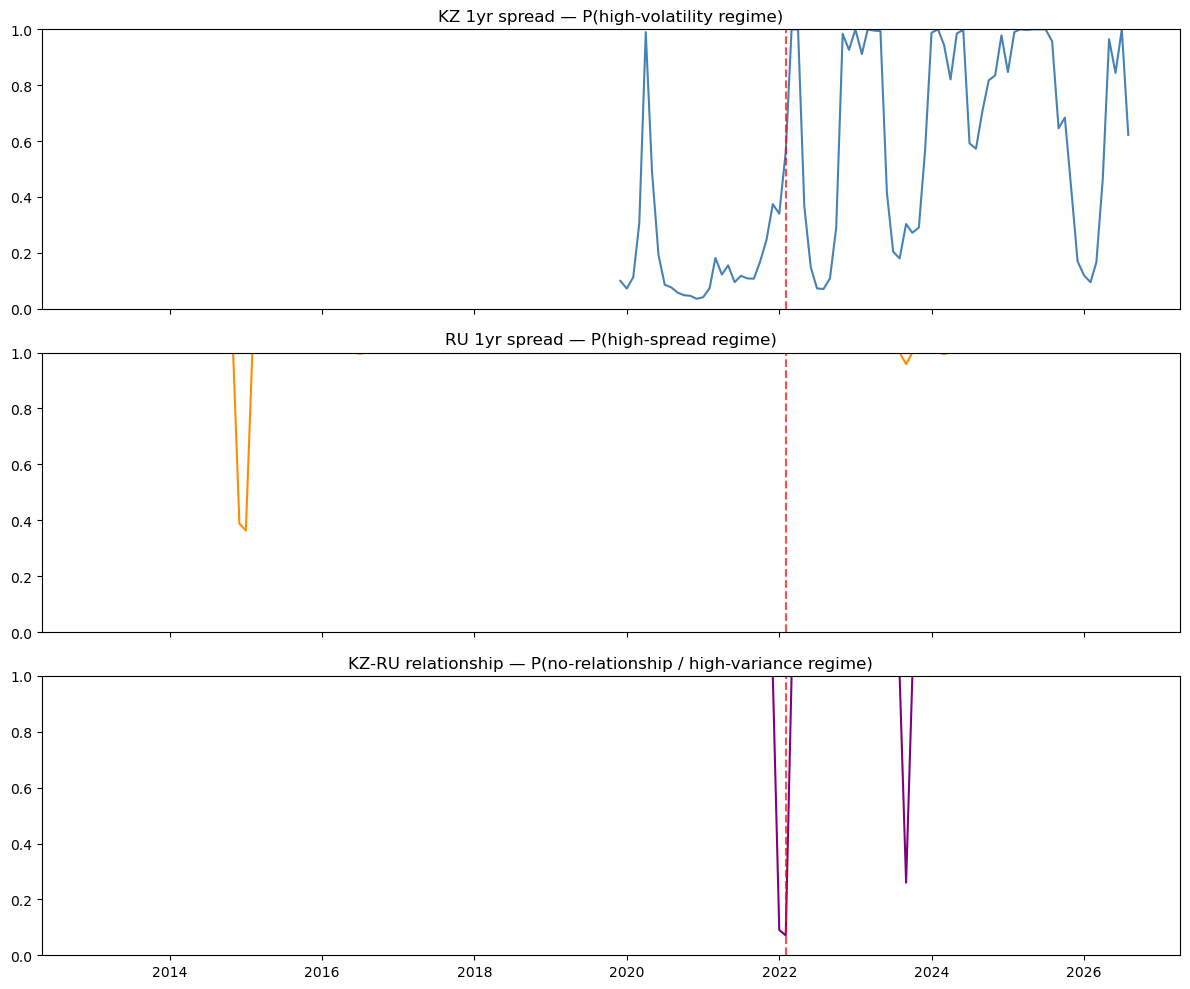

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# KZ univariate
axes[0].plot(kz_series.index, kz_fit.smoothed_marginal_probabilities[1], color="steelblue")
axes[0].axvline(war_onset, color="red", linestyle="--", alpha=0.7)
axes[0].set_title("KZ 1yr spread — P(high-volatility regime)")
axes[0].set_ylim(0, 1)

# RU univariate
axes[1].plot(ru_series.index, ru_fit.smoothed_marginal_probabilities[1], color="darkorange")
axes[1].axvline(war_onset, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("RU 1yr spread — P(high-spread regime)")
axes[1].set_ylim(0, 1)

# Relationship model
axes[2].plot(pair_df.index, relationship_fit.smoothed_marginal_probabilities[1], color="purple")
axes[2].axvline(war_onset, color="red", linestyle="--", alpha=0.7)
axes[2].set_title("KZ-RU relationship — P(no-relationship / high-variance regime)")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

#### Notebook · Block 5 · Extract exact regime-transition dates

In [5]:
def print_regime_periods(prob_series, label, threshold=0.5):
    in_regime = prob_series > threshold
    transitions = in_regime.astype(int).diff().fillna(0)
    starts = prob_series.index[transitions == 1]
    ends = prob_series.index[transitions == -1]

    print(f"\n{label} — periods with P(regime) > {threshold}:")
    if in_regime.iloc[0]:
        starts = starts.insert(0, prob_series.index[0])
    for s in starts:
        e_candidates = ends[ends > s]
        e = e_candidates[0] if len(e_candidates) > 0 else prob_series.index[-1]
        print(f"  {s.date()} to {e.date()}")

print_regime_periods(kz_fit.smoothed_marginal_probabilities[1], "KZ high-volatility regime")
print_regime_periods(ru_fit.smoothed_marginal_probabilities[1], "RU high-spread regime")
print_regime_periods(relationship_fit.smoothed_marginal_probabilities[1], "KZ-RU no-relationship regime")


KZ high-volatility regime — periods with P(regime) > 0.5:
  2020-04-01 to 2020-05-01
  2022-02-01 to 2022-05-01
  2022-11-01 to 2023-06-01
  2023-12-01 to 2025-11-01
  2026-05-01 to 2026-08-01

RU high-spread regime — periods with P(regime) > 0.5:
  2013-01-01 to 2014-12-01
  2015-02-01 to 2026-08-01

KZ-RU no-relationship regime — periods with P(regime) > 0.5:
  2019-12-01 to 2022-01-01
  2022-03-01 to 2023-09-01
  2023-10-01 to 2026-08-01


### Note: Block 5 — Corrected interpretation of regime-transition dates

**Correction:** initial visual interpretation of Panels 2 and 3 (Block 4) was
inaccurate. Exact transition dates are as follows:

**KZ high-volatility regime:** 2020-04/05; **2022-02 to 2022-05** (aligns
closely with war onset); 2022-11 to 2023-06; 2023-12 to 2025-11; 2026-05
onward. Confirms a war-aligned volatility increase with recurring episodes,
consistent with the EDA's cyclical rolling-correlation finding.

**RU high-spread regime:** 2013-01 to 2014-12, then continuously from
2015-02 to the end of the sample (2026-08) — over 11 years without exit.
The model does not detect February 2022 as a distinct event: Russia's spread
entered a persistently elevated regime around early 2015 (plausibly the 2014
oil-price crash and Crimea-related sanctions), and given this regime's
near-zero estimated exit probability, the war onset is absorbed into an
already-ongoing regime rather than triggering a new, separately identifiable
one. This is a limitation of the 2-regime specification, not evidence the
war had no effect on Russia's spread level.

**KZ-RU relationship regime:** the *significant relationship* (Regime 0) is
the rare state, appearing only in **February 2022** and **September 2023** —
single-month windows in each case. The *no-relationship* regime (Regime 1)
dominates essentially the entire remaining sample. This is the reverse of
the initial reading and represents a genuinely different, more specific
finding: rather than "relationship existed, then broke down," the evidence
supports **short, sharp episodes of contagion-like co-movement coinciding
exactly with acute shock events** (war onset; the second Russian stress
episode identified in the EDA), against a backdrop of no stable long-run
relationship between the two countries' spreads at any other time.

**Implication:** the current 2-regime RU model cannot distinguish a 2015
structural shift from a further 2022 escalation, since both are absorbed into
the same persistent regime. A 3-regime specification is a natural next step
to test whether the model can separately identify these two episodes.

#### Notebook 05 · Block 6 · 3-Regime Markov model - RU 1yr Spread

In [6]:
ru_model_3regime = MarkovRegression(
    ru_series, k_regimes=3, trend="c", switching_variance=True
)
ru_fit_3regime = ru_model_3regime.fit()
print(ru_fit_3regime.summary())

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:         ru_spread_1y_m   No. Observations:                  164
Model:               MarkovRegression   Log Likelihood                -101.581
Date:                Thu, 03 Sep 2026   AIC                            227.162
Time:                        22:57:40   BIC                            264.360
Sample:                    01-01-2013   HQIC                           242.263
                         - 08-01-2026                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2188      0.085      2.567      0.010       0.052       0.386
sigma2         0.0136      0.015      0.900      0.3

#### Notebook 05 · Block 7 · Plot + extract dates — RU 3-regime model

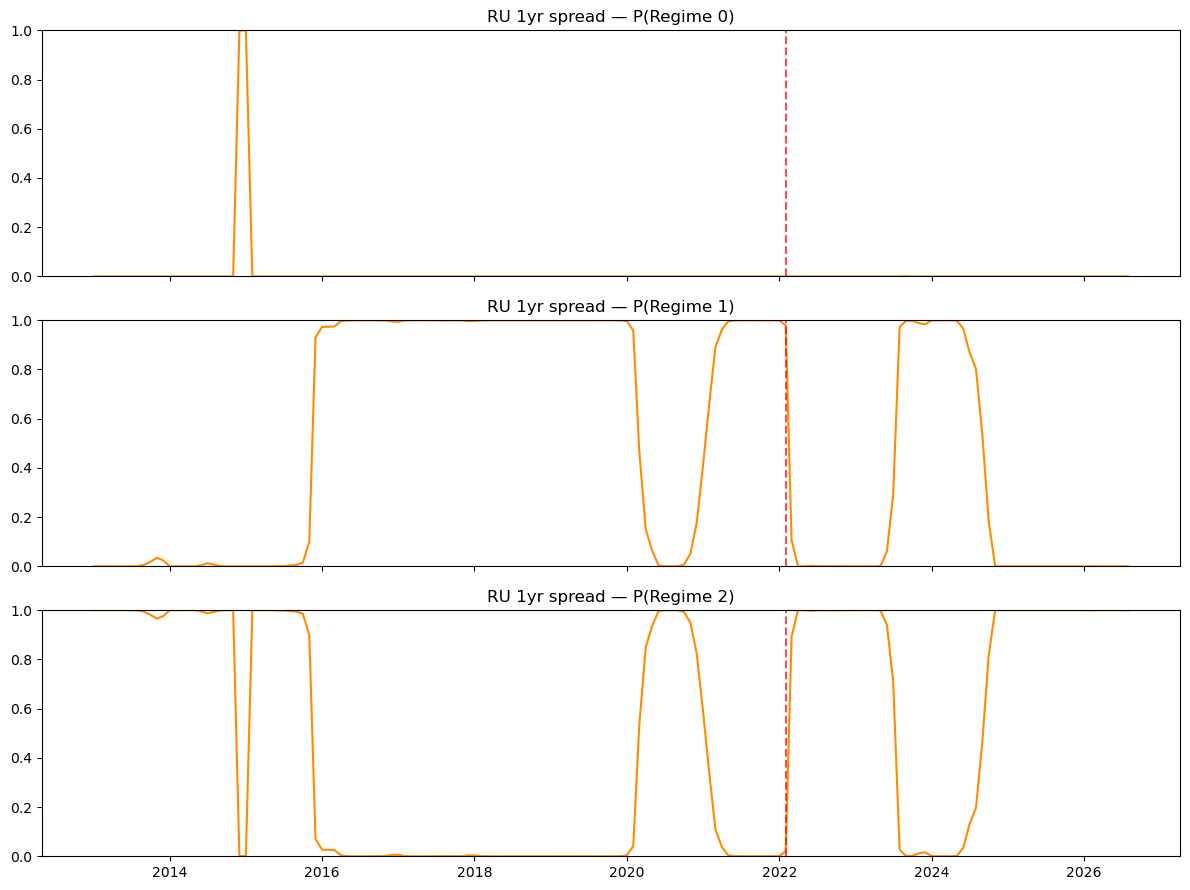


RU Regime 0 — periods with P(regime) > 0.5:
  2014-12-01 to 2015-02-01

RU Regime 1 — periods with P(regime) > 0.5:
  2015-12-01 to 2020-03-01
  2021-02-01 to 2022-03-01
  2023-08-01 to 2024-10-01

RU Regime 2 — periods with P(regime) > 0.5:
  2013-01-01 to 2014-12-01
  2015-02-01 to 2015-12-01
  2020-03-01 to 2021-02-01
  2022-03-01 to 2023-08-01
  2024-10-01 to 2026-08-01


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for i in range(3):
    axes[i].plot(ru_series.index, ru_fit_3regime.smoothed_marginal_probabilities[i], color="darkorange")
    axes[i].axvline(war_onset, color="red", linestyle="--", alpha=0.7)
    axes[i].set_title(f"RU 1yr spread — P(Regime {i})")
    axes[i].set_ylim(0, 1)
plt.tight_layout()
plt.show()

for i in range(3):
    print_regime_periods(ru_fit_3regime.smoothed_marginal_probabilities[i], f"RU Regime {i}")

#### Note: Blocks 6-7 — 3-regime Markov model, RU 1yr spread

**Model comparison:** the 3-regime specification substantially improves both
AIC (227.2 vs. 332.7) and BIC (264.4 vs. 351.3) over the 2-regime model, with
three well-separated regime means (0.22, 1.14, 2.10) — strong evidence for
genuine three-state structure rather than overfitting.

**Regime timeline (exact dates):**

| Period | Regime | Interpretation |
|---|---|---|
| 2013-01 to 2014-12 | 2 (crisis) | Pre-sample baseline crisis state |
| 2014-12 to 2015-02 | 0 (calm) | Brief transition |
| 2015-02 to 2015-12 | 2 (crisis) | Immediate post-Crimea/oil-crash period |
| 2015-12 to 2020-03 | 1 (moderate) | Post-2014 "new normal," elevated but not crisis |
| 2020-03 to 2021-02 | 2 (crisis) | COVID-19 shock |
| 2021-02 to 2022-03 | 1 (moderate) | Brief de-escalation pre-war |
| **2022-03 to 2023-08** | **2 (crisis)** | **War onset — now cleanly, separately identified** |
| 2023-08 to 2024-10 | 1 (moderate) | Partial de-escalation |
| **2024-10 to 2026-08** | **2 (crisis)** | **Second shock, confirmed as genuinely separate crisis regime** |

**Key finding:** the 3-regime model resolves the 2-regime model's central
limitation — the war (March 2022 to August 2023, ~17 months) is now
identified as its own distinct crisis episode, separate from the 2015 shock,
the COVID shock, and the late-2024 second shock. This is strong,
methodologically independent confirmation of two prior findings: (1) the war
constitutes a genuine, endogenously-detected structural break (supporting
H2), and (2) a second, statistically distinct crisis regime emerges in late
2024, corroborating the EDA's identification of a second shock episode
(Section 3) and its documented link to Russia's fiscal/monetary
deterioration (short-term yields reaching 22.78% in December 2024).

#### Notebook 05 · Block 8 · 3-regime Markov model — KZ 1yr Spread (differenced)

In [8]:
kz_model_3regime = MarkovRegression(
    kz_series, k_regimes=3, trend="c", switching_variance=True
)
kz_fit_3regime = kz_model_3regime.fit()
print(kz_fit_3regime.summary())

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:         kz_spread_1y_m   No. Observations:                   81
Model:               MarkovRegression   Log Likelihood                 -48.047
Date:                Thu, 03 Sep 2026   AIC                            120.094
Time:                        23:03:20   BIC                            148.827
Sample:                    12-01-2019   HQIC                           131.622
                         - 08-01-2026                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0610      0.032     -1.902      0.057      -0.124       0.002
sigma2         0.0151      0.005      2.950      0.0

#### Notebook 05 · Block 9 · Plot + Extract dates — KZ 3-regime model

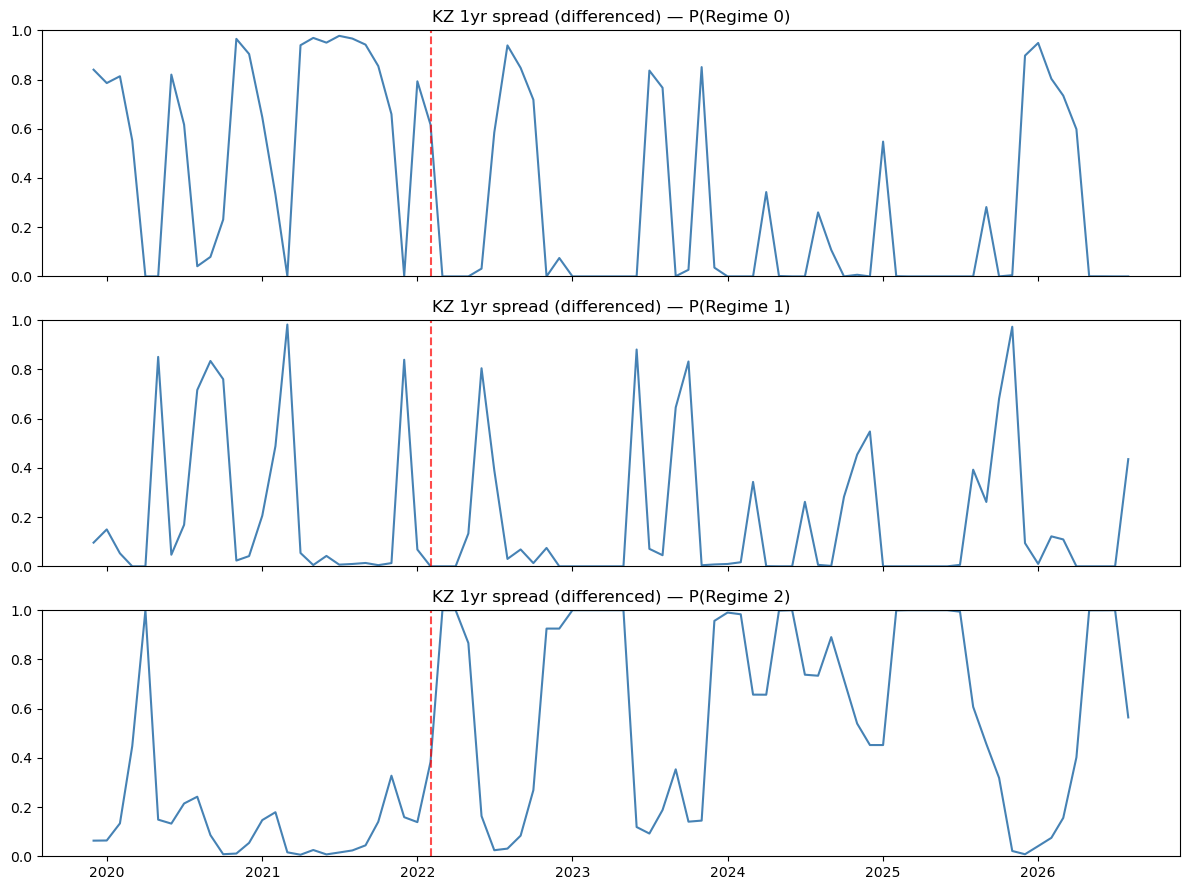


KZ Regime 0 — periods with P(regime) > 0.5:
  2019-12-01 to 2020-04-01
  2020-06-01 to 2020-08-01
  2020-11-01 to 2021-02-01
  2021-04-01 to 2021-12-01
  2022-01-01 to 2022-03-01
  2022-07-01 to 2022-11-01
  2023-07-01 to 2023-09-01
  2023-11-01 to 2023-12-01
  2025-01-01 to 2025-02-01
  2025-12-01 to 2026-05-01

KZ Regime 1 — periods with P(regime) > 0.5:
  2020-05-01 to 2020-06-01
  2020-08-01 to 2020-11-01
  2021-03-01 to 2021-04-01
  2021-12-01 to 2022-01-01
  2022-06-01 to 2022-07-01
  2023-06-01 to 2023-07-01
  2023-09-01 to 2023-11-01
  2024-12-01 to 2025-01-01
  2025-10-01 to 2025-12-01

KZ Regime 2 — periods with P(regime) > 0.5:
  2020-04-01 to 2020-05-01
  2022-03-01 to 2022-06-01
  2022-11-01 to 2023-06-01
  2023-12-01 to 2024-12-01
  2025-02-01 to 2025-09-01
  2026-05-01 to 2026-08-01

2-regime AIC/BIC: 114.4 / 128.7
3-regime AIC/BIC: 120.1 / 148.8


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for i in range(3):
    axes[i].plot(kz_series.index, kz_fit_3regime.smoothed_marginal_probabilities[i], color="steelblue")
    axes[i].axvline(war_onset, color="red", linestyle="--", alpha=0.7)
    axes[i].set_title(f"KZ 1yr spread (differenced) — P(Regime {i})")
    axes[i].set_ylim(0, 1)
plt.tight_layout()
plt.show()

for i in range(3):
    print_regime_periods(kz_fit_3regime.smoothed_marginal_probabilities[i], f"KZ Regime {i}")

print(f"\n2-regime AIC/BIC: {kz_fit.aic:.1f} / {kz_fit.bic:.1f}")
print(f"3-regime AIC/BIC: {kz_fit_3regime.aic:.1f} / {kz_fit_3regime.bic:.1f}")

#### Note: Blocks 8-9 — 3-regime model test, KZ 1yr spread (differenced)

**Model comparison:** the 3-regime specification produces worse AIC (120.1
vs. 114.4) and worse BIC (148.8 vs. 128.7) than the 2-regime model — the
opposite result from Russia (Section 5, Blocks 6-7). Two of the three
estimated regimes (0 and 2) have statistically indistinguishable means
(-0.061, p=0.057; -0.055, p=0.678), differing mainly in variance — the same
distinction already captured by the 2-regime model's calm/turbulent split.
Several transition-probability standard errors could not be estimated
(reported as NaN), consistent with the model straining against Kazakhstan's
smaller sample (81 observations) to support additional parameters.

**Conclusion:** unlike Russia, Kazakhstan's data does not support a
3-regime characterization. The 2-regime volatility-clustering model from
Block 2 — calm vs. turbulent regimes, both centered near a zero mean, with
the turbulent regime aligning closely with the war onset and recurring
cyclically thereafter — remains the appropriate and best-supported
specification for Kazakhstan. This asymmetry between the two countries'
model complexity is itself consistent with the sample-size constraint
documented throughout this paper (Kazakhstan's shorter data history,
Section 4.2) rather than a substantive economic difference in how many
regimes each country's credit market genuinely has.

#### Notebook 05 · Block 10 · 3-regime relationship model — KZ→RU

In [10]:
exog_rel = pair_df[["kz_spread_1y_m"]]

relationship_model_3regime = MarkovRegression(
    endog=pair_df["ru_spread_1y_m"],
    k_regimes=3,
    exog=exog_rel,
    trend="c",
    switching_trend=True,
    switching_exog=True,
    switching_variance=True
)
relationship_fit_3regime = relationship_model_3regime.fit()
print(relationship_fit_3regime.summary())

print(f"\n2-regime AIC/BIC: {relationship_fit.aic:.1f} / {relationship_fit.bic:.1f}")
print(f"3-regime AIC/BIC: {relationship_fit_3regime.aic:.1f} / {relationship_fit_3regime.bic:.1f}")

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:         ru_spread_1y_m   No. Observations:                   81
Model:               MarkovRegression   Log Likelihood                 -60.806
Date:                Thu, 03 Sep 2026   AIC                            151.612
Time:                        23:10:28   BIC                            187.528
Sample:                    12-01-2019   HQIC                           166.022
                         - 08-01-2026                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5306      0.018     29.392      0.000       0.495       0.566
x1            -0.3316      0.054     -6.185      0.0

#### Notebook 05 · Block 11 · Plot + Extract dates — 3-Regime relationship model

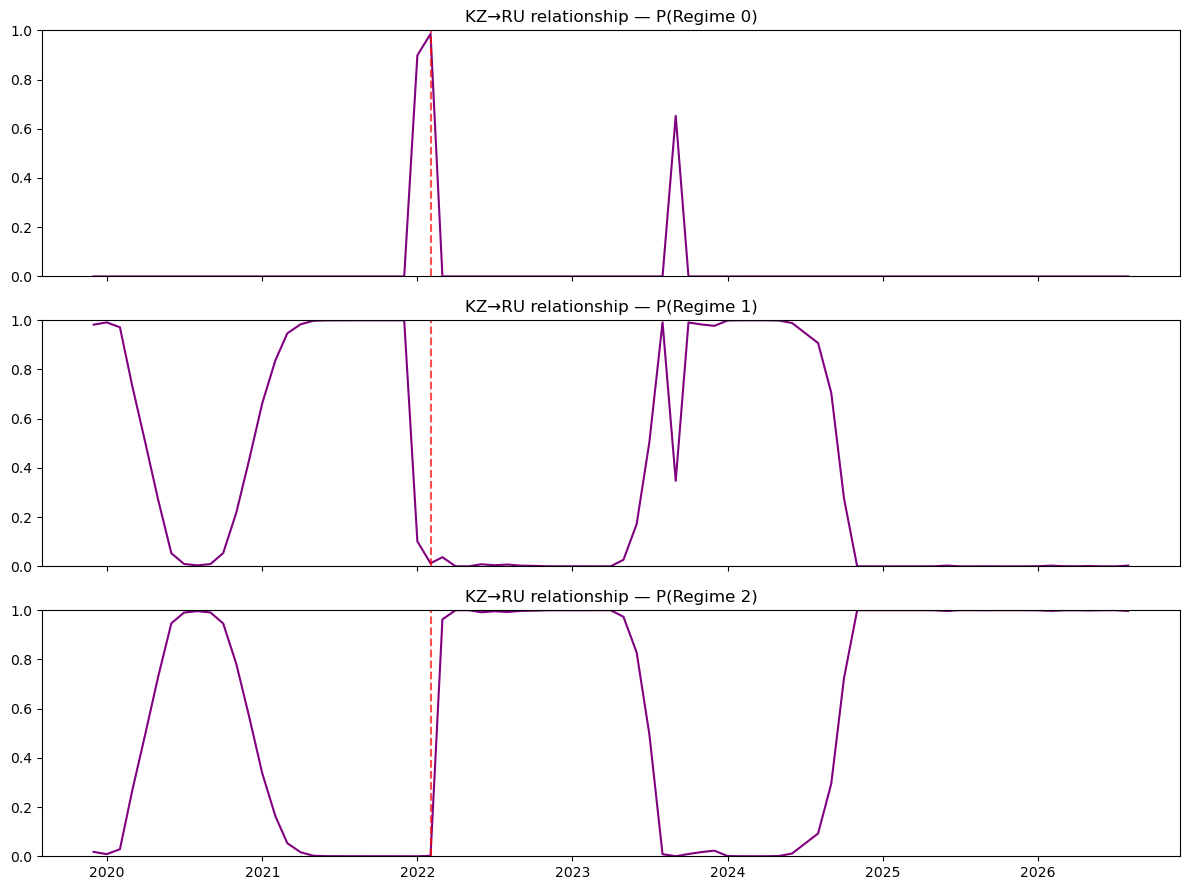


Relationship Regime 0 — periods with P(regime) > 0.5:
  2022-01-01 to 2022-03-01
  2023-09-01 to 2023-10-01

Relationship Regime 1 — periods with P(regime) > 0.5:
  2019-12-01 to 2020-05-01
  2021-01-01 to 2022-01-01
  2023-07-01 to 2023-09-01
  2023-10-01 to 2024-10-01

Relationship Regime 2 — periods with P(regime) > 0.5:
  2020-05-01 to 2021-01-01
  2022-03-01 to 2023-07-01
  2024-10-01 to 2026-08-01


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for i in range(3):
    axes[i].plot(pair_df.index, relationship_fit_3regime.smoothed_marginal_probabilities[i], color="purple")
    axes[i].axvline(war_onset, color="red", linestyle="--", alpha=0.7)
    axes[i].set_title(f"KZ→RU relationship — P(Regime {i})")
    axes[i].set_ylim(0, 1)
plt.tight_layout()
plt.show()

for i in range(3):
    print_regime_periods(relationship_fit_3regime.smoothed_marginal_probabilities[i], f"Relationship Regime {i}")

#### Note: Blocks 10-11 — 3-regime KZ→RU relationship model

**Model comparison:** the 3-regime specification improves both AIC (151.6
vs. 180.1) and BIC (187.5 vs. 199.3) over the 2-regime version — supported
by the data, unlike Kazakhstan's own univariate series.

**Regime characterization:** only Regime 0 (intercept 0.531, slope -0.332,
p<0.001) shows a statistically significant KZ-RU relationship. Regimes 1
and 2 show no significant relationship (slopes -0.188, p=0.264 and -0.007,
p=0.955 respectively), differing from each other mainly in RU's spread
level (moderate vs. high) — corresponding to RU's own moderate and crisis
regimes from its univariate model.

**Exact timeline:** the significant-relationship regime (Regime 0) occurs
only in two brief windows — **January-March 2022** (the war onset) and
**September-October 2023** — while the no-relationship, high-spread regime
(Regime 2) dominates March 2022 to July 2023 and again from October 2024
onward, closely matching Russia's own crisis-regime dating from its
univariate 3-regime model (Section 5, Blocks 6-7).

**Refined finding:** the relationship between KZ's and RU's credit spreads
becomes briefly, sharply significant only at the *onset* of a shock — both
countries' spreads move together in the initial transition moment — but the
relationship then disappears for the full duration of the subsequent crisis
period, even as Russia's own spread remains persistently elevated. This
refines the earlier "contagion" framing (Section 5, Block 3) into a more
precise claim: initial shock transmission between the two countries is
detectable, but each country's crisis dynamics subsequently decouple and
evolve independently, driven by country-specific factors rather than a
continuing shared shock.

### 5.12 Summary and Implications for VAR/IRF Analysis

This section synthesizes the Markov-switching results from Sections 5.1–5.11
ahead of the VAR/IRF analysis (Section 6).

### Method and rationale
Markov-switching models were used to test, endogenously, whether the war
produced a detectable regime shift — without assuming its timing in advance.
This was directly motivated by the ARDL results (Section 4.6), where a
simple war dummy failed to capture any statistically significant effect,
indicating that a level-shift specification is inadequate for this question.

### Kazakhstan: a 2-regime, volatility-driven structure
Kazakhstan's differenced 1yr spread supports only a 2-regime specification
(a 3-regime model was tested and rejected on both AIC and BIC grounds,
Section 5.5). The two regimes are distinguished primarily by **volatility**,
not level: neither regime's mean is statistically distinguishable from zero,
but the turbulent regime's variance is roughly 10x the calm regime's. The
turbulent regime aligns closely with the war onset (February–May 2022) and
recurs cyclically through 2026, consistent with the exploratory rolling-
correlation finding (Section 3) of repeated, non-permanent divergence
episodes rather than a single clean break.

### Russia: a 3-regime, level-and-volatility structure with two distinct crisis episodes
Russia's level spread strongly supports a 3-regime specification (improving
both AIC and BIC substantially over 2 regimes, Section 5.4). This
refinement resolves a key limitation of the 2-regime model, which absorbed
the war into an already-ongoing high-spread regime dating to 2015. The
3-regime model instead identifies:

| Period | Regime |
|---|---|
| 2013–early 2015 | Crisis (pre-sample baseline) |
| Late 2015–March 2020 | Moderate ("new normal" post-2014) |
| March 2020–Feb 2021 | Crisis (COVID-19) |
| Feb 2021–March 2022 | Moderate |
| **March 2022–August 2023** | **Crisis (war)** |
| August 2023–October 2024 | Moderate |
| **October 2024–2026** | **Crisis (second shock)** |

This provides methodologically independent confirmation of two prior
findings: (1) the war constitutes a genuine, endogenously-detected
structural break, supporting H2; and (2) a second, statistically distinct
crisis regime emerges in late 2024, corroborating the exploratory finding
(Section 3) linked to Russia's documented fiscal and monetary deterioration
(short-term yields reaching 22.78% in December 2024).

### The KZ-RU relationship: transient shock transmission, not sustained divergence
A regime-switching regression of Russia's spread on Kazakhstan's spread
(Section 5.3, refined to 3 regimes in Section 5.7) reveals a more precise
pattern than either country's univariate model alone. A statistically
significant relationship between the two countries' spreads exists only in
two brief windows — January–March 2022 (war onset) and September–October
2023 — while a no-relationship, high-spread regime dominates the remainder
of each crisis period (March 2022–July 2023; October 2024 onward), closely
tracking Russia's own crisis-regime dating.

This refines the paper's divergence narrative: rather than a sustained loss
of comovement, the evidence supports **transient shock transmission at the
moment of onset, followed by decoupling as each country's crisis dynamics
proceed independently** — a more specific and economically informative claim
than a simple correlation breakdown.

### Carrying forward to Section 6 (VAR/IRF)
1. Russia's confirmed war-period regime (March 2022–August 2023) and second
   crisis regime (October 2024 onward) provide precise windows for
   structural break analysis in the VAR specification, rather than relying
   solely on the assumed February 2022 date.
2. The finding that KZ-RU comovement is transient and onset-specific, not
   sustained, suggests the VAR/IRF analysis should examine impulse
   responses in short windows around each shock's onset, rather than
   assuming a uniform post-war impulse-response structure across the entire
   2022–2026 period.
3. Kazakhstan's volatility-driven (not level-driven) regime structure
   suggests its VAR specification may benefit from explicitly modeling
   conditional volatility alongside the mean equation, rather than a
   standard constant-variance VAR.